IMPORTAÇÃO DAS BIBLIOTECAS PANDAS E MATPLOTLIB

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

CARREGANDO O ARQUIVO VENDAS.CSV EM UM DATA FRAME

In [2]:
df = pd.read_csv('/content/vendas.csv')

LEITURA DOS  PRIMEIROS REGISTROS

In [3]:
df.head()

,id_venda,data_venda,id_cliente,id_produto,produto,categoria,valor_venda,quantidade
0,1,2023-02-07,109,8,Livro: A Guerra dos Tronos,Livros,2677.12,2
1,2,2023-01-11,139,7,Headset Surround 7.1,Áudio,1210.10,1
2,3,2023-02-16,104,17,Mousepad Gamer XXL,Periféricos,2393.06,2
3,4,2023-03-20,145,17,Mousepad Gamer XXL,Periféricos,3925.92,3
4,5,2023-02-16,134,16,Memória RAM 16GB DDR5,Componentes,4702.89,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_venda     120 non-null    int64  
 1   data_venda   120 non-null    object 
 2   id_cliente   120 non-null    int64  
 3   id_produto   120 non-null    int64  
 4   produto      120 non-null    object 
 5   categoria    120 non-null    object 
 6   valor_venda  120 non-null    float64
 7   quantidade   120 non-null    int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 7.6+ KB


In [5]:
df

,id_venda,data_venda,id_cliente,id_produto,produto,categoria,valor_venda,quantidade
0,1,2023-02-07,109,8,Livro: A Guerra dos Tronos,Livros,2677.12,2
1,2,2023-01-11,139,7,Headset Surround 7.1,Áudio,1210.10,1
2,3,2023-02-16,104,17,Mousepad Gamer XXL,Periféricos,2393.06,2
3,4,2023-03-20,145,17,Mousepad Gamer XXL,Periféricos,3925.92,3
4,5,2023-02-16,134,16,Memória RAM 16GB DDR5,Componentes,4702.89,1
...,...,...,...,...,...,...,...,...
115,116,2023-01-26,143,19,Livro: Duna,Livros,991.78,1
116,117,2023-01-07,103,10,Mesa Digitalizadora,Periféricos,4726.90,2
117,118,2023-03-07,101,11,Luminária de Mesa LED,Decoração,4242.74,2
118,119,2023-01-24,128,9,Webcam 4K,Periféricos,800.63,3


VERIFICAÇÃO DE DADOS AUSENTE

In [9]:
df[df['valor_venda'].isna()]

,id_venda,data_venda,id_cliente,id_produto,produto,categoria,valor_venda,quantidade


In [10]:
df[df['quantidade'].isna()]

,id_venda,data_venda,id_cliente,id_produto,produto,categoria,valor_venda,quantidade


In [11]:
# Filtra o DataFrame para mostrar apenas as linhas com algum NaN
linhas_com_nan = df[df.isnull().any(axis=1)]
display(linhas_com_nan)

,id_venda,data_venda,id_cliente,id_produto,produto,categoria,valor_venda,quantidade


VERIFICAÇÃO DE DADOS DUPLICADOS

In [12]:
# Conta o total de linhas duplicadas
total_duplicados = df.duplicated().sum()
print(f"Existem {total_duplicados} linhas duplicadas.")

Existem 0 linhas duplicadas.


In [13]:
# Mostra as linhas que são duplicadas
df[df.duplicated(keep=False)]

,id_venda,data_venda,id_cliente,id_produto,produto,categoria,valor_venda,quantidade


CÁLCULO DE FATURAMENTO TOTAL POR CADA LINHA E COLUNA FATURAMENTO

In [14]:
df['faturamento'] = df['valor_venda'] * df['quantidade']
df

,id_venda,data_venda,id_cliente,id_produto,produto,categoria,valor_venda,quantidade,faturamento
0,1,2023-02-07,109,8,Livro: A Guerra dos Tronos,Livros,2677.12,2,5354.24
1,2,2023-01-11,139,7,Headset Surround 7.1,Áudio,1210.10,1,1210.10
2,3,2023-02-16,104,17,Mousepad Gamer XXL,Periféricos,2393.06,2,4786.12
3,4,2023-03-20,145,17,Mousepad Gamer XXL,Periféricos,3925.92,3,11777.76
4,5,2023-02-16,134,16,Memória RAM 16GB DDR5,Componentes,4702.89,1,4702.89
...,...,...,...,...,...,...,...,...,...
115,116,2023-01-26,143,19,Livro: Duna,Livros,991.78,1,991.78
116,117,2023-01-07,103,10,Mesa Digitalizadora,Periféricos,4726.90,2,9453.80
117,118,2023-03-07,101,11,Luminária de Mesa LED,Decoração,4242.74,2,8485.48
118,119,2023-01-24,128,9,Webcam 4K,Periféricos,800.63,3,2401.89


EXTRAINDO O MES DA DATA_VENDA

In [16]:
mes = df['data_venda'].str.split('-', expand=True)[1]
mes

,1
0,02
1,01
2,02
3,03
4,02
...,...
115,01
116,01
117,03
118,01


AGRUPAMENTO DE DADOS POR MES E FATURAMENTO

In [17]:
df_mes = df.groupby(mes)[['faturamento']].sum()
df_mes

,faturamento
1,
01,234634.61
02,282351.34
03,293842.93


In [18]:
# Agrupa todas as colunas numéricas pela variável 'mes'
df_mes_total = df.groupby(mes).sum()
df_mes_total

,id_venda,data_venda,id_cliente,id_produto,produto,categoria,valor_venda,quantidade,faturamento
1,,,,,,,,,
01,2366,2023-01-112023-01-202023-01-022023-01-022023-0...,4336,315,Headset Surround 7.1Luminária de Mesa LEDSmart...,ÁudioDecoraçãoEletrônicosPeriféricosPeriférico...,94959.93,82,234634.61
02,2378,2023-02-072023-02-162023-02-162023-02-202023-0...,5438,453,Livro: A Guerra dos TronosMousepad Gamer XXLMe...,LivrosPeriféricosComponentesPeriféricosPerifér...,115948.18,107,282351.34
03,2516,2023-03-202023-03-222023-03-052023-03-162023-0...,5124,390,Mousepad Gamer XXLLivro: DunaNotebook GamerLiv...,PeriféricosLivrosEletrônicosLivrosPeriféricosP...,118189.46,102,293842.93


AGRUPAMENTO DE DADOS POR CATEGORIA E FATURAMENTO

In [19]:
df_categoria = df.groupby('categoria')[['faturamento']].sum()
df_categoria
#

,faturamento
categoria,
Colecionáveis,55658.46
Componentes,35468.07
Decoração,109156.43
Eletrônicos,124973.54
Livros,140285.75
Móveis,8083.34
Periféricos,307921.82
Áudio,29281.47


GRÁFICO DE LINHA FATURAMENTO POR MES

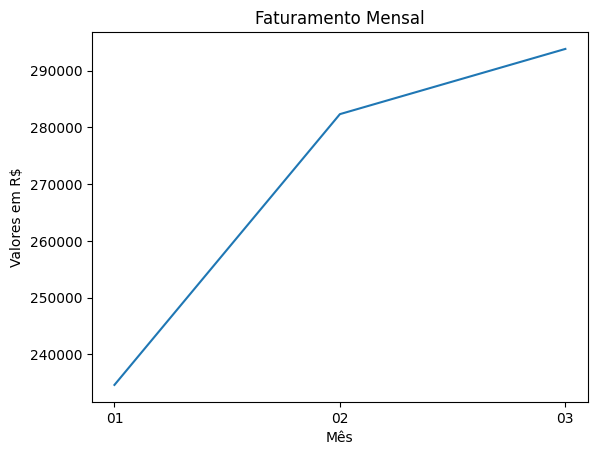

In [20]:
import matplotlib.pyplot as plt

# Dados de exemplo (x seriam os meses, y o faturamento)
plt.plot(df_mes.index.astype(str), df_mes['faturamento'])

# Personalização essencial
plt.title('Faturamento Mensal')
plt.xlabel('Mês')
plt.ylabel('Valores em R$')

# Exibe o gráfico
plt.show()

GRÁFICO DE BARRAS FATURAMENTO POR CATEGORIA

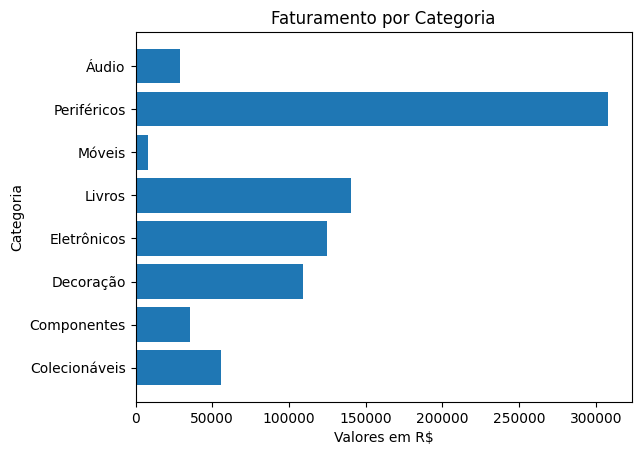

In [23]:
import matplotlib.pyplot as plt

# Dados de exemplo (x seria o faturamento, y a categoria)
plt.barh(df_categoria.index.astype(str), df_categoria['faturamento'])

# Personalização essencial
plt.title('Faturamento por Categoria')
plt.xlabel('Valores em R$')
plt.ylabel('Categoria')

# Exibe o gráfico
plt.show()